# Kaggle Dataset Explorer
## Schnelle Datenanalyse für Portfolio-Projekte

Dieses Notebook hilft dir dabei, Kaggle-Datasets schnell zu explorieren und zu entscheiden, ob sie für dein Portfolio-Projekt geeignet sind.

---

## 1. Setup & Daten laden



In [125]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from core.data import load_from_kaggle
import kagglehub


# Styling für bessere Visualisierungen
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100



In [126]:
# ===== HIER DATASET-LINK EINFÜGEN =====
full_link = r"https://www.kaggle.com/datasets/madhankumar789/crop-yield-and-environmental-factors-2014-2023"
dataset_link = full_link.split("/datasets/")[-1]
# ======================================

destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

print(f"📦 Lade Dataset: {dataset_name}")
files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
)

print(f"✅ {len(files)} Datei(en) gefunden:")
for i, file in enumerate(files, 1):
    print(f"   {i}. {file}")

📦 Lade Dataset: crop-yield-and-environmental-factors-2014-2023
Destination directory '../data/raw\crop-yield-and-environmental-factors-2014-2023' already exists with files. Skipping download (replace=False).
✅ 1 Datei(en) gefunden:
   1. crop_yield_dataset.csv




## 2. Daten einlesen & erste Inspektion



In [127]:

# Erste CSV-Datei laden (oder bei Bedarf anpassen)
file_path = "/".join([destination, dataset_name, files[0]])
df = pd.read_csv(file_path)

print(f"📊 Geladene Datei: {files[0]}")
print(f"📏 Shape: {df.shape[0]:,} Zeilen × {df.shape[1]} Spalten\n")

df.sample(10)


📊 Geladene Datei: crop_yield_dataset.csv
📏 Shape: 36,520 Zeilen × 12 Spalten



,Date,Crop_Type,Soil_Type,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality
22408,2020-02-19,Potato,Clay,6.25,19.071362,80.000000,6.436319,66.0,50.0,36.0,66.124147,44.333333
21427,2019-11-13,Tomato,Sandy,6.75,19.311540,80.000000,7.989393,50.0,36.0,30.0,22.852667,33.833333
576,2014-02-27,Sugarcane,Sandy,6.75,18.240686,80.000000,12.267565,65.0,48.0,36.0,22.710178,43.458333
18154,2018-12-21,Soybean,Saline,8.00,18.415365,80.000000,8.551084,58.5,55.0,49.5,48.979828,13.583333
36302,2023-12-10,Rice,Clay,6.25,18.979771,80.000000,9.494286,78.0,60.0,44.0,39.679457,53.083333
3122,2014-11-09,Rice,Peaty,5.50,21.189376,78.810624,9.236176,71.5,54.0,38.5,36.097035,27.333333
9232,2016-07-12,Rice,Sandy,6.75,39.259409,60.740591,11.251674,65.0,48.0,33.0,0.000000,42.583333
26767,2021-04-30,Tomato,Clay,6.25,19.947866,80.000000,8.025143,60.0,45.0,40.0,29.421996,42.291667
33621,2023-03-17,Corn,Loamy,6.50,20.762271,79.237729,10.882674,84.0,66.0,50.0,107.225301,66.666667
23404,2020-05-29,Soybean,Saline,8.00,29.845112,70.154888,17.963297,58.5,55.0,49.5,0.665076,13.583333




---

## 3. Datenqualität & Struktur



In [128]:

print("=" * 80)
print("📋 DATENÜBERSICHT")
print("=" * 80)

# Grundlegende Statistiken
print(f"\n🔢 Dimensionen: {df.shape[0]:,} Zeilen × {df.shape[1]} Spalten")
print(f"🔄 Duplikate: {df.duplicated().sum():,} ({df.duplicated().sum()/len(df)*100:.2f}%)")
print(f"💾 Speichernutzung: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")



📋 DATENÜBERSICHT

🔢 Dimensionen: 36,520 Zeilen × 12 Spalten
🔄 Duplikate: 0 (0.00%)
💾 Speichernutzung: 8.37 MB


In [129]:
# Detaillierte Spaltenübersicht
column_info = pd.DataFrame({
    "Datentyp": df.dtypes,
    "Fehlende Werte": df.isnull().sum(),
    "Fehlend %": (df.isnull().sum() / len(df) * 100).round(2),
    "Unique Werte": df.nunique(),
    "Beispielwerte": [df[col].dropna().sample(min(3, df[col].notna().sum())).tolist() 
                      if df[col].notna().sum() > 0 else [] 
                      for col in df.columns]
})

column_info = column_info.sort_values("Fehlend %", ascending=False)
column_info


,Datentyp,Fehlende Werte,Fehlend %,Unique Werte,Beispielwerte
Date,object,0,0.0,3652,"[2018-01-24, 2015-05-09, 2023-01-13]"
Crop_Type,object,0,0.0,10,"[Wheat, Barley, Potato]"
Soil_Type,object,0,0.0,5,"[Loamy, Clay, Saline]"
Soil_pH,float64,0,0.0,5,"[6.5, 6.5, 6.75]"
Temperature,float64,0,0.0,36520,"[40.533552121436585, 29.763936848354746, 17.53..."
Humidity,float64,0,0.0,22906,"[62.09514879459741, 66.34313585943295, 73.4937..."
Wind_Speed,float64,0,0.0,36520,"[7.482912892281624, 8.661647726588832, 9.72195..."
N,float64,0,0.0,20,"[78.0, 55.0, 71.5]"
P,float64,0,0.0,16,"[48.0, 54.0, 36.0]"
K,float64,0,0.0,18,"[31.5, 45.0, 38.5]"


In [130]:
#Type conversion
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

df["Crop_Type"] = df["Crop_Type"].astype("category")
df["Soil_Type"] = df["Soil_Type"].astype("category")




---

## 4. Numerische Variablen analysieren



In [131]:

# Statistiken für numerische Spalten
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if numeric_cols:
    print(f"📊 {len(numeric_cols)} numerische Spalten gefunden\n")
    display(df[numeric_cols].describe().round(2).T)
else:
    print("⚠️ Keine numerischen Spalten gefunden")



📊 10 numerische Spalten gefunden



,count,mean,std,min,25%,50%,75%,max
Soil_pH,36520.0,6.60,0.82,5.50,6.25,6.50,6.75,8.00
Temperature,36520.0,23.81,8.92,-3.54,17.17,22.90,30.25,54.15
Humidity,36520.0,74.26,6.77,45.85,69.75,77.10,80.00,80.00
Wind_Speed,36520.0,10.02,3.00,-3.39,7.99,10.00,12.04,22.61
N,36520.0,66.01,10.89,45.00,58.50,65.00,71.50,91.00
P,36520.0,53.01,8.81,36.00,45.00,54.00,60.00,72.00
K,36520.0,42.02,8.54,27.00,35.00,42.00,49.50,60.00
Crop_Yield,36520.0,26.88,25.74,0.00,0.00,23.37,46.42,136.71
Soil_Quality,36520.0,37.52,17.70,13.29,22.50,35.58,49.29,74.33
Month,36520.0,6.52,3.45,1.00,4.00,7.00,10.00,12.00


In [132]:
# Negative Wind Speed!
neg_wind = df[df['Wind_Speed'] < 0]
print(f"Number of rows with negative wind speed: {len(neg_wind)}, Percentage: {len(neg_wind) / len(df) * 100:.2f}%")
n_negative = (df['Wind_Speed'] < 0).sum()
print(f"Clipping {n_negative} negative Wind_Speed values to 0")
df['Wind_Speed'] = df['Wind_Speed'].clip(lower=0)

Number of rows with negative wind speed: 15, Percentage: 0.04%
Clipping 15 negative Wind_Speed values to 0


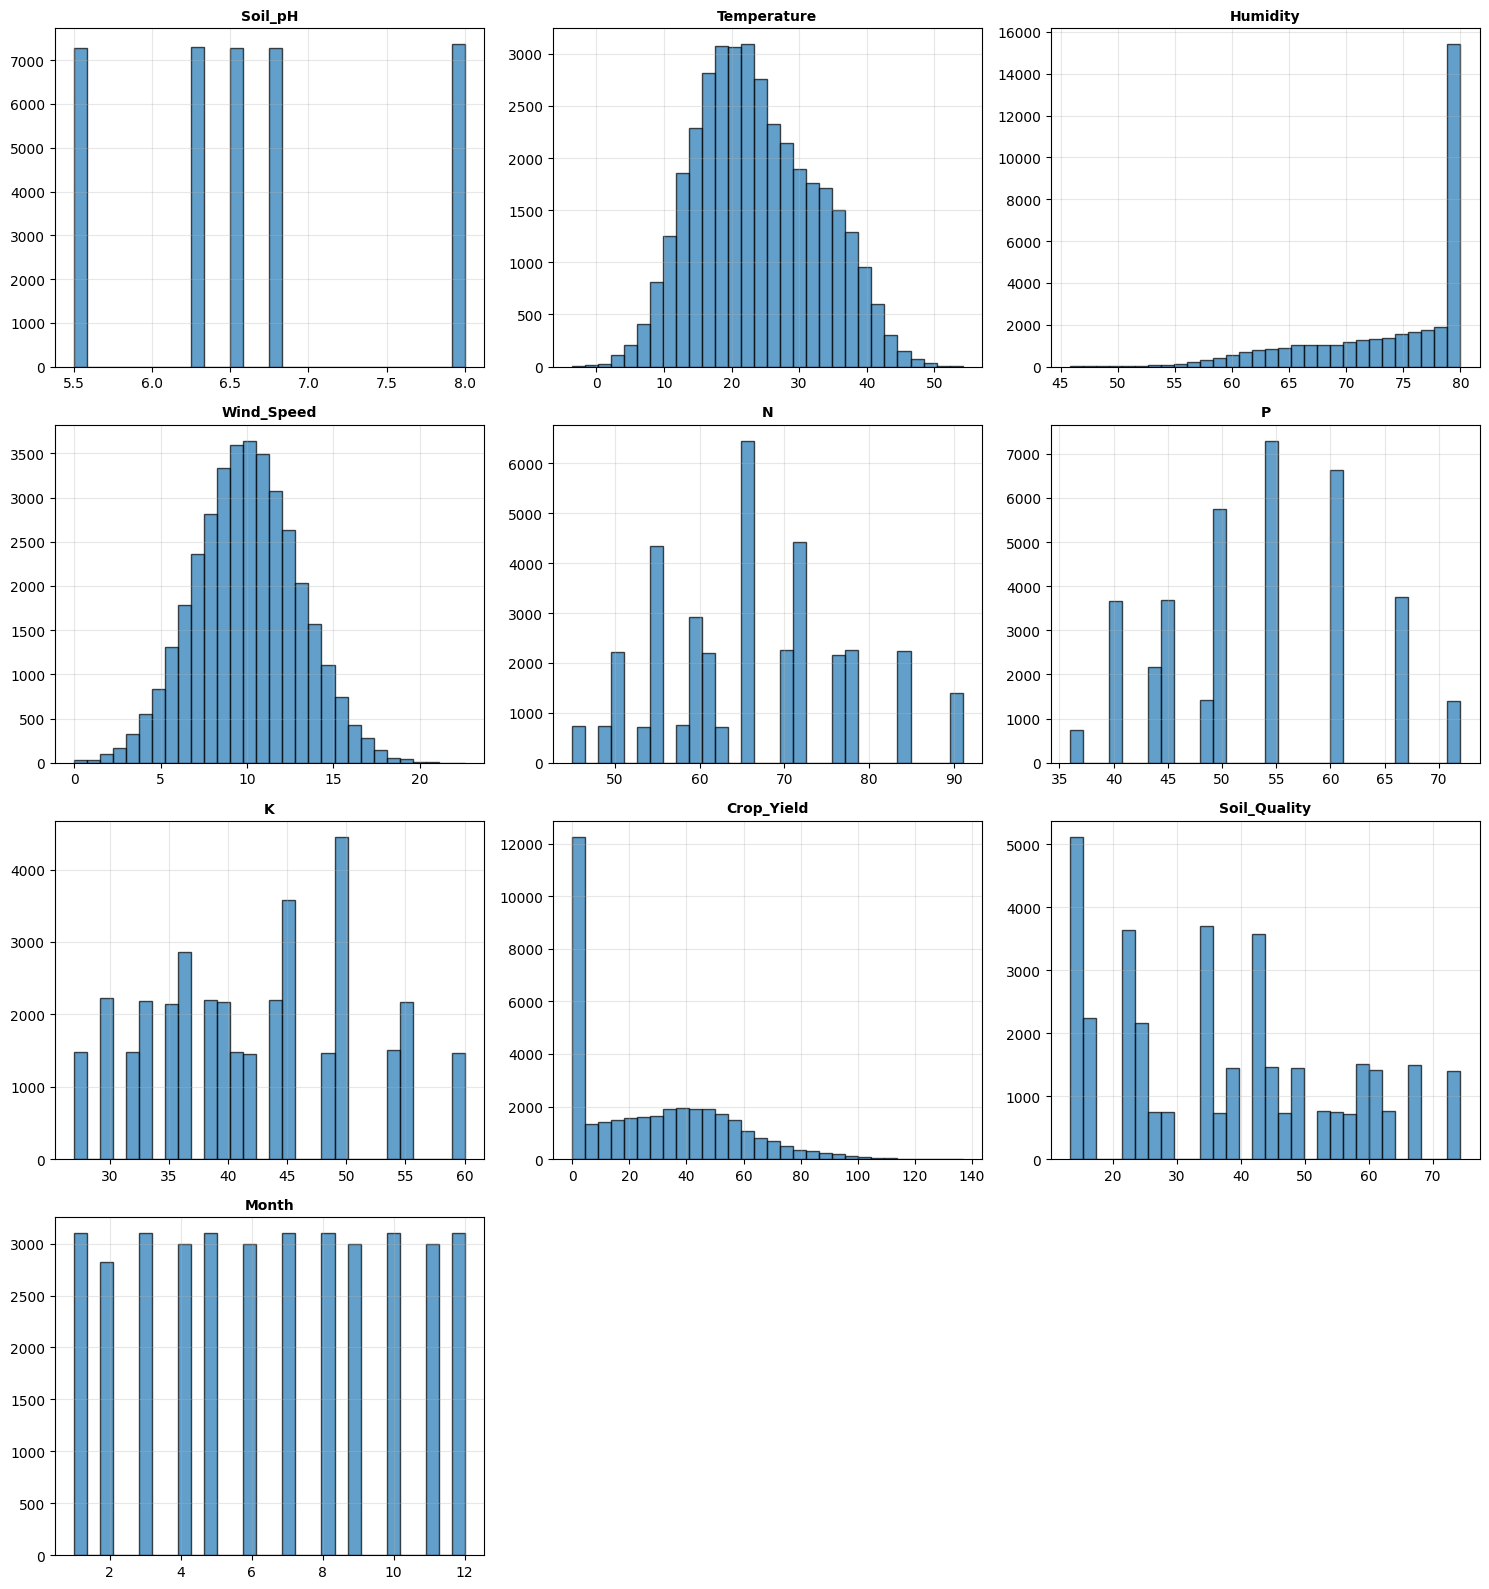

In [133]:
# Verteilungen der numerischen Variablen
if numeric_cols:
    n_cols = min(3, len(numeric_cols))
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten() if len(numeric_cols) > 1 else [axes]
    
    for idx, col in enumerate(numeric_cols):
        ax = axes[idx]
        df[col].hist(bins=30, ax=ax, edgecolor='black', alpha=0.7)
        ax.set_title(f'{col}', fontsize=10, fontweight='bold')
        ax.grid(alpha=0.3)
    
    # Leere Subplots ausblenden
    for idx in range(len(numeric_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()


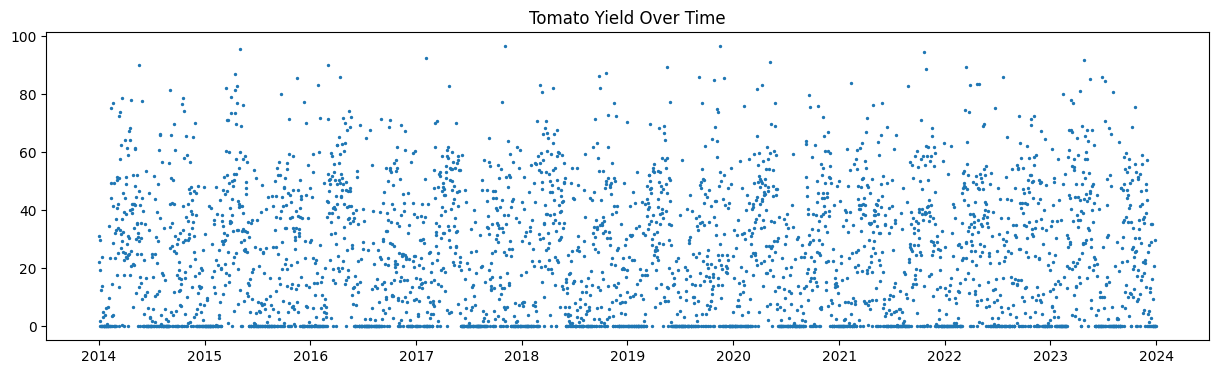

Month
1     0.503226
2     0.475177
3     0.058065
4     0.036667
5     0.045161
6     0.496667
7     0.496774
8     0.561290
9     0.163333
10    0.138710
11    0.110000
12    0.487097
Name: Crop_Yield, dtype: float64


In [134]:
# Zero spike in crop yield for example Tomato
tomato = df[df['Crop_Type'] == 'Tomato'].copy()

plt.figure(figsize=(15,4))
plt.scatter(tomato['Date'], tomato['Crop_Yield'], s=2)
plt.title('Tomato Yield Over Time')
plt.show()

tomato['Month'] = tomato['Date'].dt.month

is_zero = tomato['Crop_Yield'] == 0
zero_rate_by_month = is_zero.groupby(tomato['Month']).mean()
print(zero_rate_by_month)
df_nonzero = df[df['Crop_Yield'] > 0].copy()  # excludes zeros

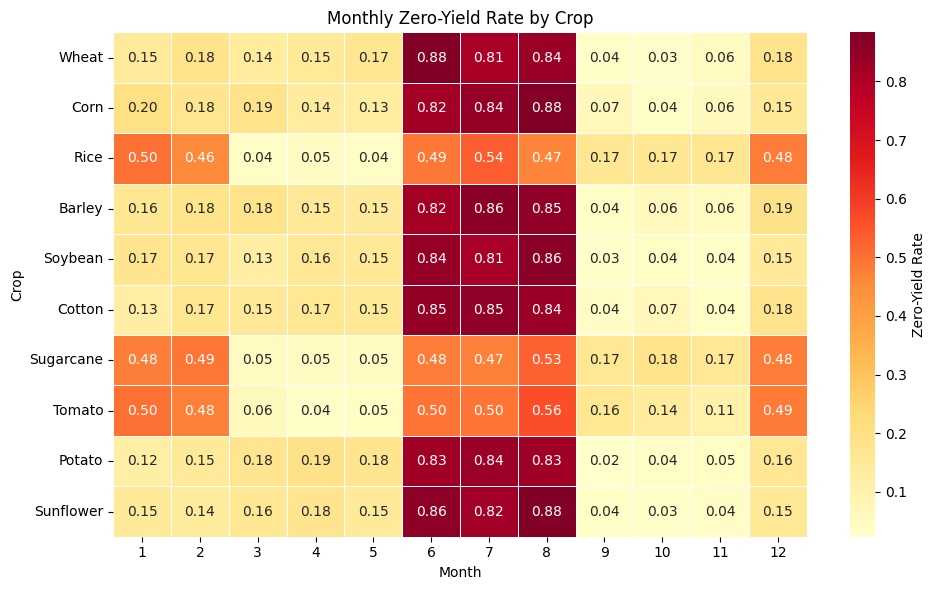

In [135]:
# Overview for all crops
crops = df['Crop_Type'].unique()

zero_rates = {}
for crop in crops:
    crop_df = df[df['Crop_Type'] == crop].copy()
    is_zero = crop_df['Crop_Yield'] == 0
    monthly_rates = is_zero.groupby(crop_df['Month']).mean()
    zero_rates[crop] = monthly_rates

df_heat = pd.DataFrame(zero_rates).T
df_heat.columns.name = 'Month'

plt.figure(figsize=(10, 6))
sns.heatmap(df_heat, cmap='YlOrRd', annot=True, fmt='.2f', linewidths=0.5,
            cbar_kws={'label': 'Zero-Yield Rate'})
plt.title('Monthly Zero-Yield Rate by Crop')
plt.xlabel('Month')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()

From the heatmap one can clearly see two kinds of crops:  
  - unimodal crops with high zero rates in summer (wheat, corn, barley, soybean, cotton, potato, and sunflower)  
  - bimodal crops with high zero rates (smaller scale) in summer and winter (rice, sugarcane, and tomato)
  - seasonal pattern obvious 
    
This will be considered for feature engineering: creating a season feature reducing 12 features to 4 

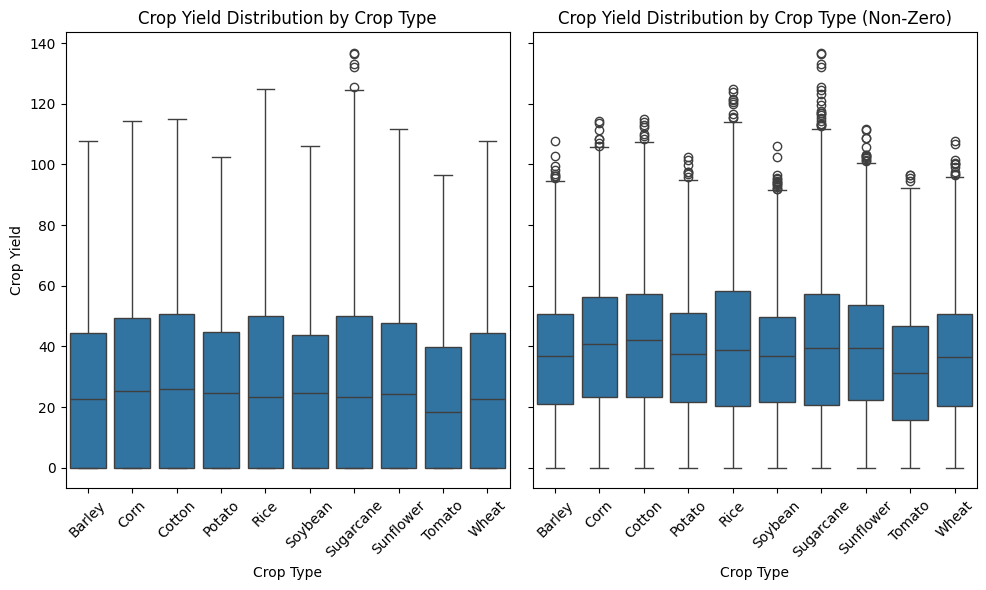

In [136]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 6), sharey=True)
sns.boxplot(df, x='Crop_Type', y='Crop_Yield', ax=ax[0])
sns.boxplot(df_nonzero, x='Crop_Type', y='Crop_Yield', ax=ax[1])
ax[0].set_title('Crop Yield Distribution by Crop Type')
ax[0].set_ylabel('Crop Yield')
ax[0].set_xlabel('Crop Type')
ax[1].set_title('Crop Yield Distribution by Crop Type (Non-Zero)')
ax[1].set_ylabel('Crop Yield')
ax[1].set_xlabel('Crop Type')
ax[0].tick_params(axis='x', rotation=45)
ax[1].tick_params(axis='x', rotation=45)
ax[1].tick_params(axis='y', labelleft=False)  # Hide y-axis labels on the second plot
fig.tight_layout()


C:\Users\Brassac\AppData\Local\Temp\ipykernel_4500\369177872.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_hum = df.groupby(['Crop_Type', 'humidity_bin_mid'])['Crop_Yield'].mean().reset_index()
C:\Users\Brassac\AppData\Local\Temp\ipykernel_4500\369177872.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_temp = df.groupby(['Crop_Type', 'temp_bin_mid'])['Crop_Yield'].mean().reset_index()


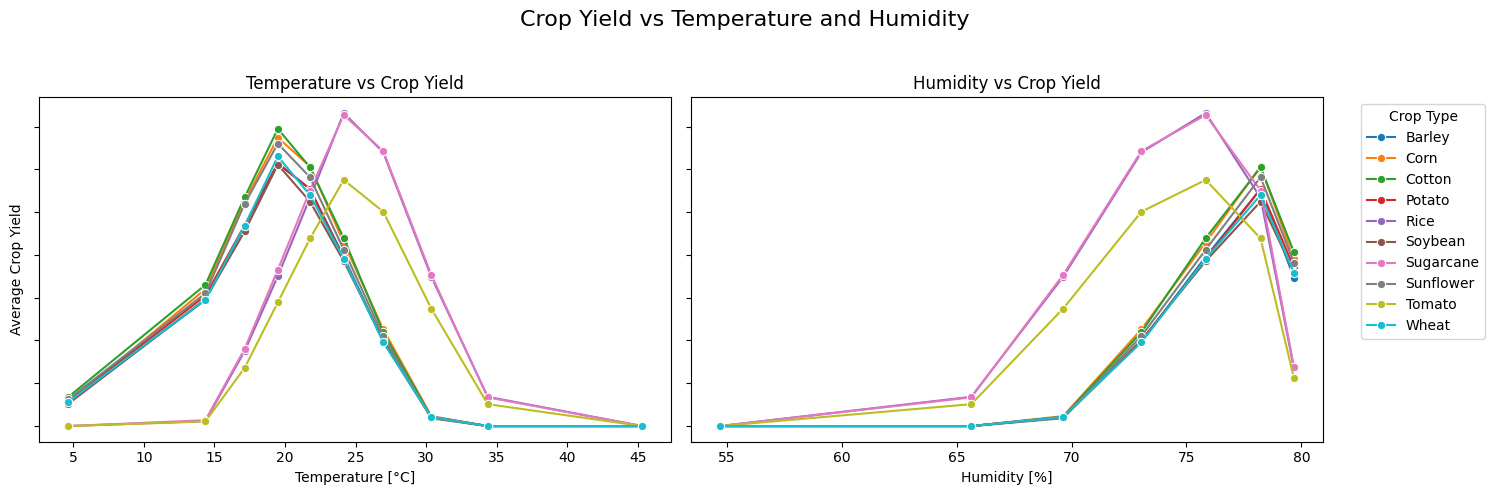

In [137]:
# Humidity and Temperature vs Crop Yield
df['humidity_bin'] = pd.qcut(df['Humidity'], q=10, duplicates='drop')

# Numeric midpoint for each bin, useful for plotting as a continuous x-axis
df['humidity_bin_mid'] = df['humidity_bin'].apply(lambda x: x.mid).astype(float)
binned_hum = df.groupby(['Crop_Type', 'humidity_bin_mid'])['Crop_Yield'].mean().reset_index()

df['temp_bin'] = pd.qcut(df['Temperature'], q=10, duplicates='drop')
df['temp_bin_mid'] = df['temp_bin'].apply(lambda x: x.mid).astype(float)

binned_temp = df.groupby(['Crop_Type', 'temp_bin_mid'])['Crop_Yield'].mean().reset_index()

fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

sns.lineplot(x='temp_bin_mid', y='Crop_Yield', hue='Crop_Type', marker='o', data=binned_temp, ax=ax[0], legend=False)
sns.lineplot(x='humidity_bin_mid', y='Crop_Yield', hue='Crop_Type', marker='o', data=binned_hum, ax=ax[1])

fig.suptitle('Crop Yield vs Temperature and Humidity', fontsize=16)
ax[0].set_title('Temperature vs Crop Yield')
ax[0].set_xlabel('Temperature [°C]')
ax[0].set_ylabel('Average Crop Yield')
ax[1].set_title('Humidity vs Crop Yield')
ax[1].set_xlabel('Humidity [%]')
ax[1].set_yticklabels([])  # Hide y-tick labels for the second plot
ax[1].legend(title='Crop Type', bbox_to_anchor=(1.05, 1), loc='upper left')
fig.tight_layout(rect=[0, 0, 1, 0.95])

df = df.drop(columns=['humidity_bin', 'humidity_bin_mid', 'temp_bin', 'temp_bin_mid'])

The same two kinds of crops is also visible here : Rice-Sugarcane-Tomato vs. the rest.

C:\Users\Brassac\AppData\Local\Temp\ipykernel_4500\2208745464.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = df.groupby(['Crop_Type', 'wind_bin_mid'])['Crop_Yield'].mean().reset_index()


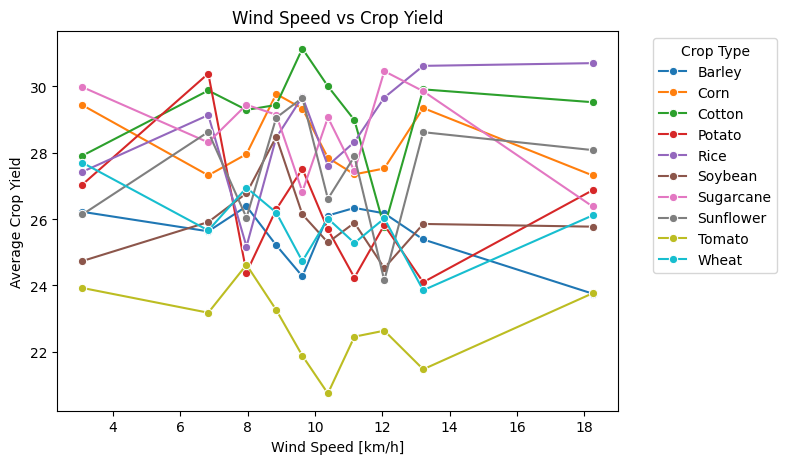

In [138]:
# Wind_speed vs Crop Yield
df['wind_bin'] = pd.qcut(df['Wind_Speed'], q=10, duplicates='drop')

# Numeric midpoint for each bin
df['wind_bin_mid'] = df['wind_bin'].apply(lambda x: x.mid).astype(float)
binned = df.groupby(['Crop_Type', 'wind_bin_mid'])['Crop_Yield'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(x='wind_bin_mid', y='Crop_Yield', hue='Crop_Type', marker='o', data=binned, legend=True)
#fig.suptitle('Crop Yield vs Wind Speed', fontsize=16)
ax.set_title('Wind Speed vs Crop Yield')
ax.set_xlabel('Wind Speed [km/h]')
ax.set_ylabel('Average Crop Yield')
ax.legend(title='Crop Type', bbox_to_anchor=(1.05, 1), loc='upper left')
fig.tight_layout(rect=[0, 0, 1, 0.95])

df = df.drop(columns=['wind_bin', 'wind_bin_mid'])

Wind looks random 

C:\Users\Brassac\AppData\Local\Temp\ipykernel_4500\3527156159.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = df.groupby(['Crop_Type', 'pH_bin_mid'])['Crop_Yield'].mean().reset_index()
C:\Users\Brassac\AppData\Local\Temp\ipykernel_4500\3527156159.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_soil = df.groupby(['Crop_Type', 'soil_bin_mid'])['Crop_Yield'].mean().reset_index()


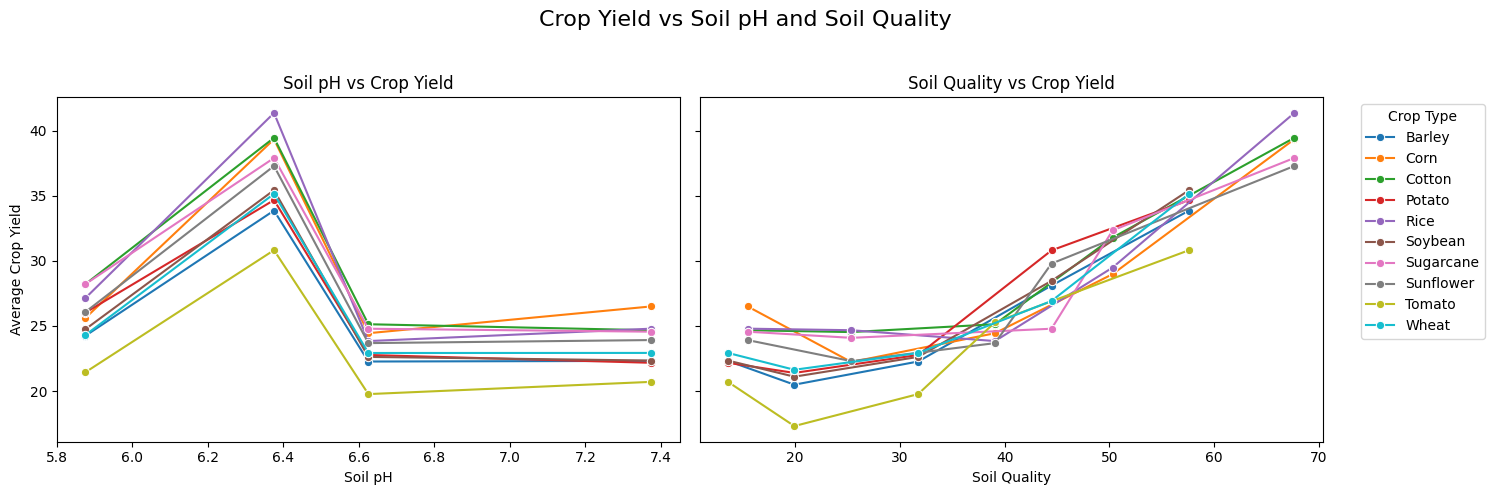

In [139]:
# Soil pH vs Crop Yield
df['pH_bin'] = pd.qcut(df['Soil_pH'], q=10, duplicates='drop')

# Numeric midpoint for each bin
df['pH_bin_mid'] = df['pH_bin'].apply(lambda x: x.mid).astype(float)
binned = df.groupby(['Crop_Type', 'pH_bin_mid'])['Crop_Yield'].mean().reset_index()

df['soil_bin'] = pd.qcut(df['Soil_Quality'], q=10, duplicates='drop')
df['soil_bin_mid'] = df['soil_bin'].apply(lambda x: x.mid).astype(float)

binned_soil = df.groupby(['Crop_Type', 'soil_bin_mid'])['Crop_Yield'].mean().reset_index()

fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
sns.lineplot(x='pH_bin_mid', y='Crop_Yield', hue='Crop_Type', marker='o',  data=binned, ax=ax[0], legend=False)
sns.lineplot(x='soil_bin_mid', y='Crop_Yield', hue='Crop_Type', marker='o', data=binned_soil, ax=ax[1])
fig.suptitle('Crop Yield vs Soil pH and Soil Quality', fontsize=16)
ax[1].set_title('Soil Quality vs Crop Yield')
ax[1].set_xlabel('Soil Quality')
ax[1].set_ylabel('Average Crop Yield')
ax[0].set_title('Soil pH vs Crop Yield')
ax[0].set_xlabel('Soil pH')
ax[0].set_ylabel('Average Crop Yield')
ax[1].legend(title='Crop Type', bbox_to_anchor=(1.05, 1), loc='upper left')
fig.tight_layout(rect=[0, 0, 1, 0.95])

df = df.drop(columns=['pH_bin', 'pH_bin_mid', 'soil_bin', 'soil_bin_mid'])

Soil pH, similar profile for all crops, unimodal      
Soil quality positively correlated with Yield

C:\Users\Brassac\AppData\Local\Temp\ipykernel_4500\4071535661.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_nutrient = df.groupby(['Crop_Type', f'{nutrient}_bin_mid'])['Crop_Yield'].mean().reset_index()
C:\Users\Brassac\AppData\Local\Temp\ipykernel_4500\4071535661.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_nutrient = df.groupby(['Crop_Type', f'{nutrient}_bin_mid'])['Crop_Yield'].mean().reset_index()
C:\Users\Brassac\AppData\Local\Temp\ipykernel_4500\4071535661.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas

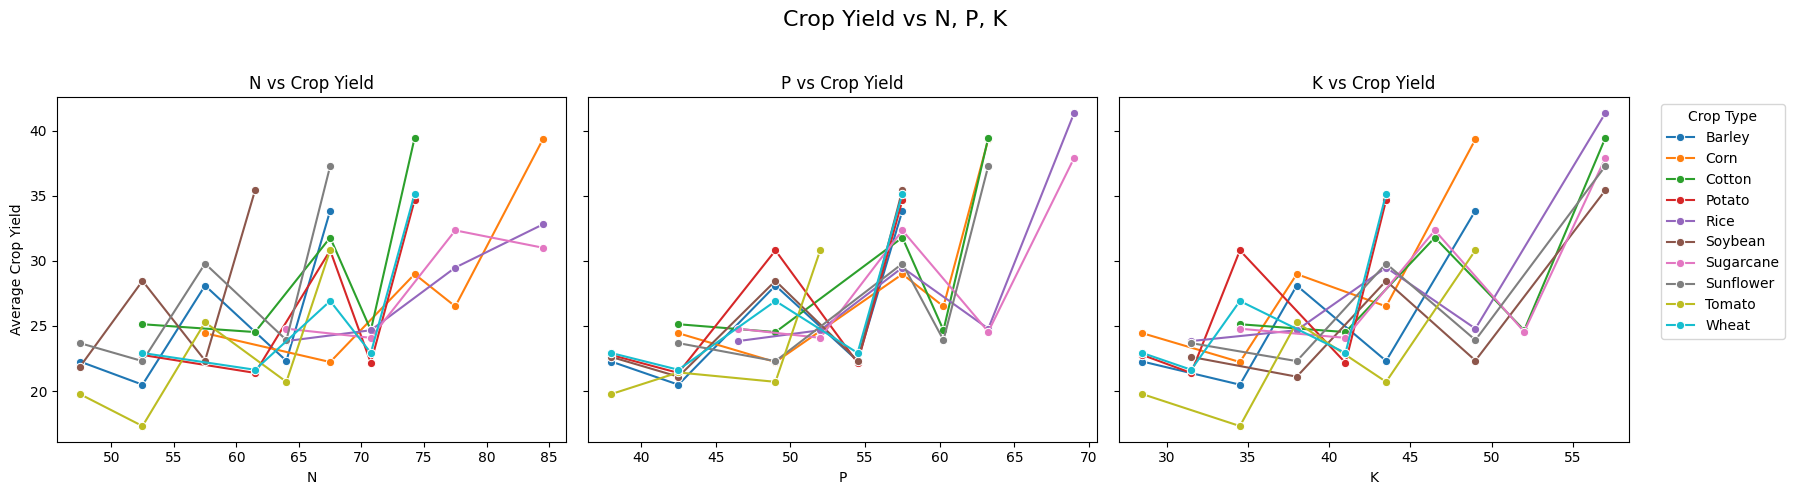

In [140]:
for nutrient in ['N', 'P', 'K']:
    bins = pd.qcut(df[nutrient], q=10, duplicates='drop')
    df[f'{nutrient}_bin_mid'] = bins.apply(lambda x: x.mid).astype(float)

fig, ax = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, nutrient in enumerate(['N', 'P', 'K']):
    binned_nutrient = df.groupby(['Crop_Type', f'{nutrient}_bin_mid'])['Crop_Yield'].mean().reset_index()
    legend = (i == 2)  # only show legend on last plot
    sns.lineplot(x=f'{nutrient}_bin_mid', y='Crop_Yield', hue='Crop_Type', marker='o',
                 data=binned_nutrient, ax=ax[i], legend=legend)
    ax[i].set_title(f'{nutrient} vs Crop Yield')
    ax[i].set_xlabel(nutrient)

ax[0].set_ylabel('Average Crop Yield')
ax[2].legend(title='Crop Type', bbox_to_anchor=(1.05, 1), loc='upper left')
fig.suptitle('Crop Yield vs N, P, K', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])

df = df.drop(columns=['N_bin_mid', 'P_bin_mid', 'K_bin_mid'])

Up and downs for the fertilizers taken individually, probably a question of optimal balance, to be considered for feature engineering.

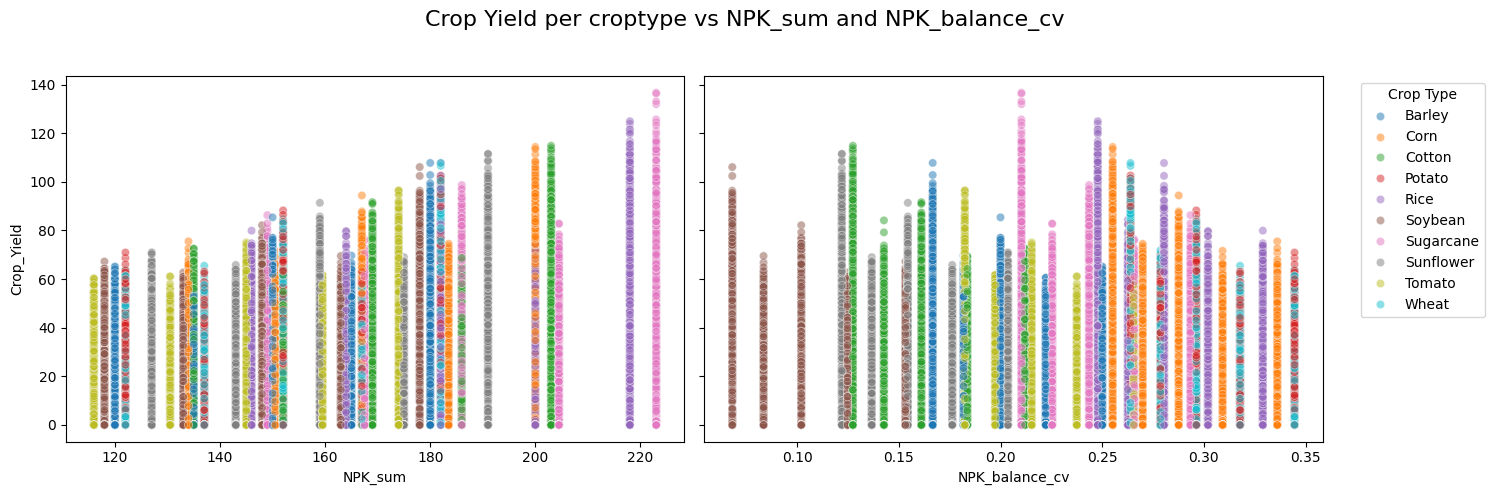

In [141]:
# NPK Features
df['NPK_sum'] = df['N'] + df['P'] + df['K']
df['NPK_balance_cv'] = df[['N','P','K']].std(axis=1) / df[['N','P','K']].mean(axis=1) # low = balanced, high = skewed
df["N_ratio"]= df['N'] / df['NPK_sum']
df["P_ratio"]= df['P'] / df['NPK_sum']
df["K_ratio"]= df['K'] / df['NPK_sum']


fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
sns.scatterplot(x='NPK_sum', y='Crop_Yield', data=df, hue='Crop_Type', ax=ax[0], alpha=0.5, legend=False)
sns.scatterplot(x='NPK_balance_cv', y='Crop_Yield', data=df, hue='Crop_Type', ax=ax[1], alpha=0.5)
ax[1].legend(title='Crop Type', bbox_to_anchor=(1.05, 1), loc='upper left')
fig.suptitle('Crop Yield per croptype vs NPK_sum and NPK_balance_cv', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])



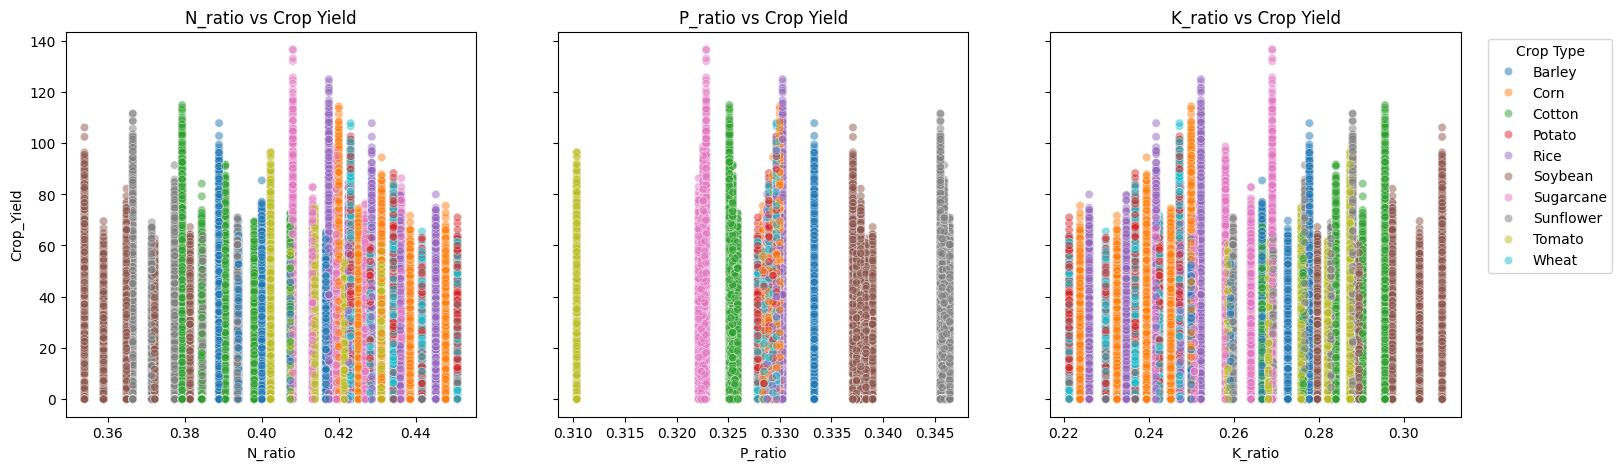

In [142]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, nutrient in enumerate(['N_ratio', 'P_ratio', 'K_ratio']):
    sns.scatterplot(x=nutrient, y='Crop_Yield', data=df, hue='Crop_Type', ax=ax[i], alpha=0.5, legend=(i==2))
    ax[i].set_title(f'{nutrient} vs Crop Yield')
    ax[i].set_xlabel(nutrient)  
ax[2].legend(title='Crop Type', bbox_to_anchor=(1.05, 1), loc='upper left')

In [162]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

features = ['N', 'P', 'K', 'Temperature', 'Humidity', 'Wind_Speed', 'Soil_pH']
X = df[features].dropna()
vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

       Feature         VIF
0            N  272.029835
1            P  764.414595
2            K  209.407480
3  Temperature    9.158985
4     Humidity   64.393676
5   Wind_Speed   12.087423
6      Soil_pH   71.427123


In [163]:
features = ['N_ratio', 'P_ratio', "NPK_sum", 'Temperature', 'Humidity', 'Wind_Speed', 'Soil_pH']
X = df[features].dropna()
vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

       Feature         VIF
0      N_ratio  225.563259
1      P_ratio  765.700182
2      NPK_sum   41.713016
3  Temperature   49.375663
4     Humidity  711.928345
5   Wind_Speed   12.153878
6      Soil_pH   71.865801


=== Pearson correlation with Month ===
Temperature    0.011835
Soil_pH       -0.002682
Humidity       0.002240
K             -0.000749
P             -0.000654
NPK_sum       -0.000636
N             -0.000436
Name: Month, dtype: float64

=== Monthly means ===
               N          P          K     NPK_sum  Temperature   Humidity  \
Month                                                                        
1      66.202258  53.194839  42.194194  161.591290    15.168296  79.515552   
2      65.821631  52.826241  41.829965  160.477837    14.997073  79.596244   
3      65.823226  52.824032  41.825484  160.472742    25.024847  74.542227   
4      66.200500  53.197667  42.213000  161.611167    25.001683  74.600656   
5      65.973548  52.998710  42.003710  160.975968    24.974444  74.605980   
6      65.999333  53.010333  42.018333  161.028000    34.988671  65.008140   
7      66.064355  53.073387  42.083226  161.220968    34.882152  65.113918   
8      66.052581  53.060484  42.059194  

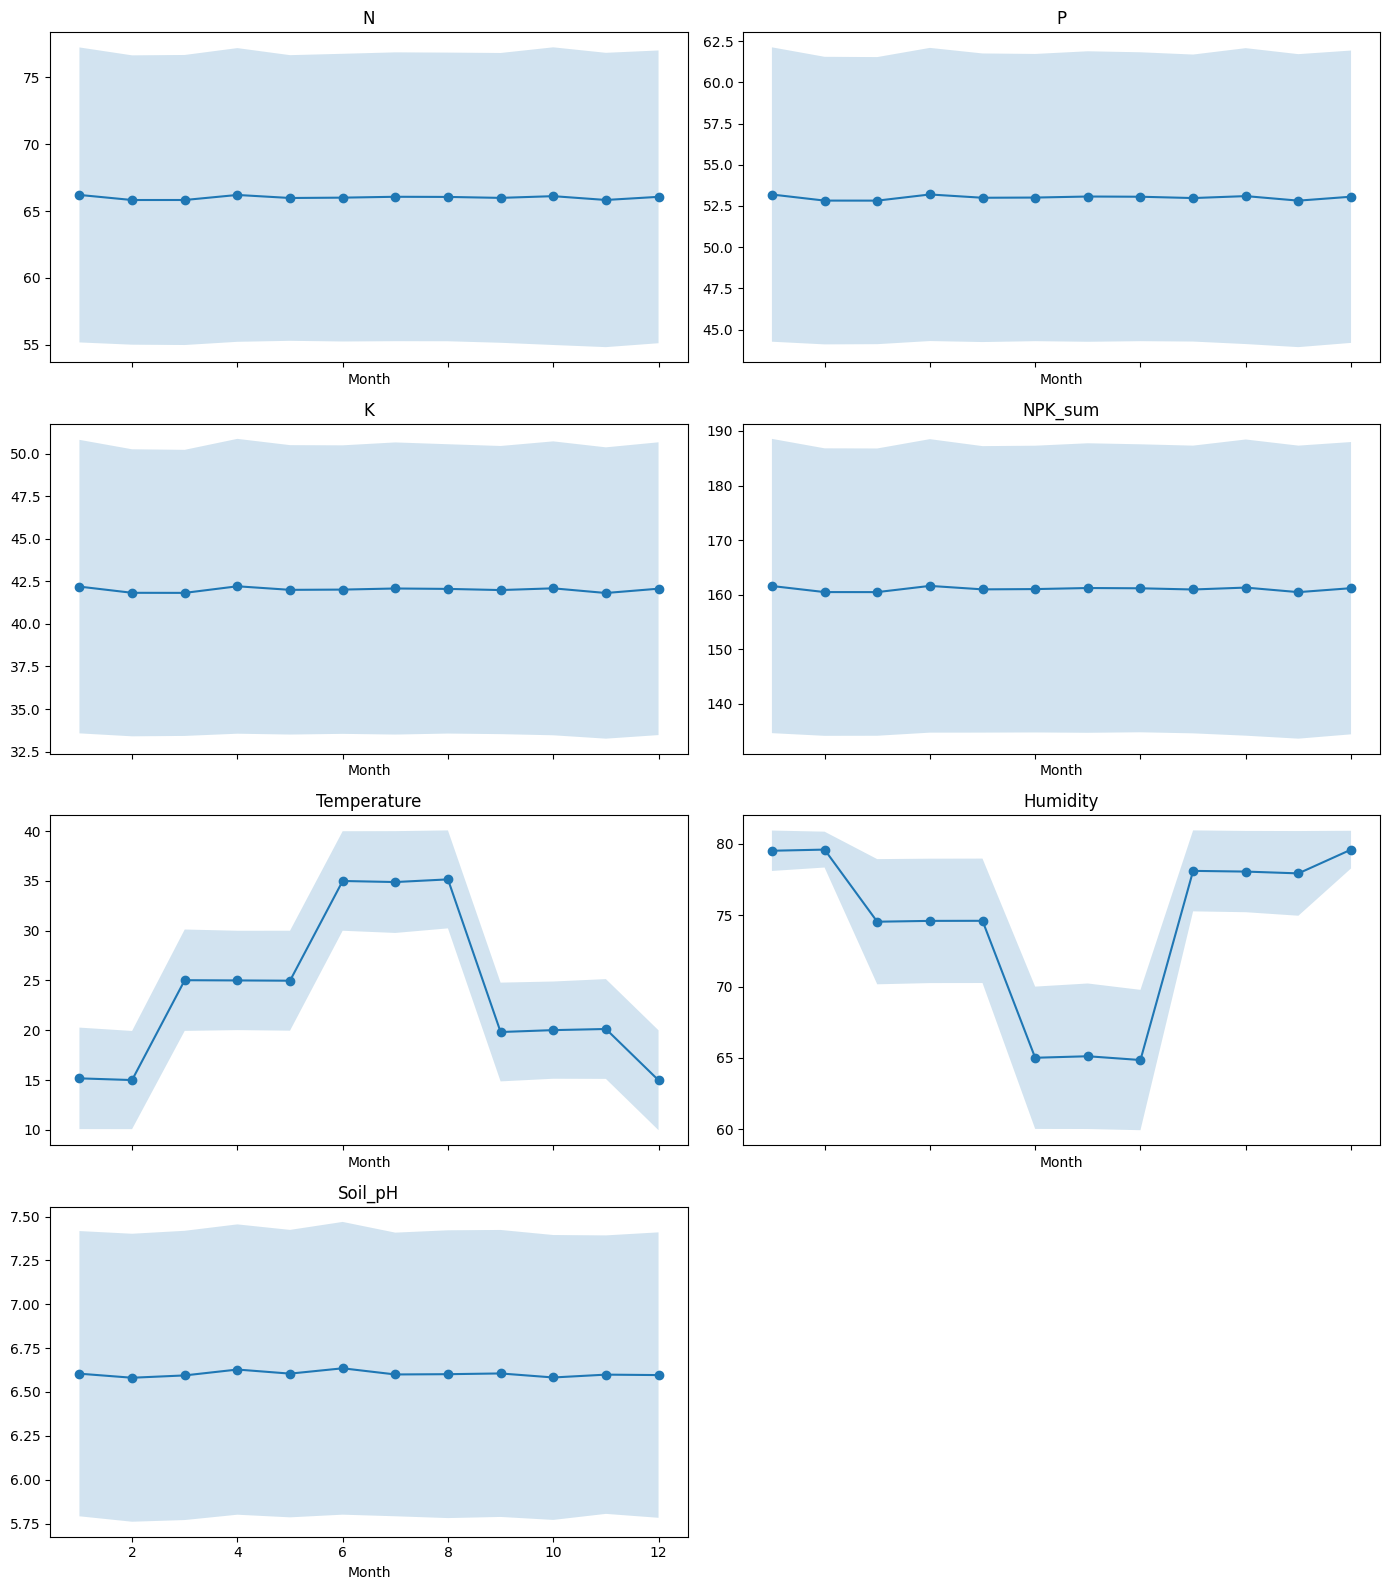


=== One-way ANOVA: variable ~ Month ===
N             F=     0.46  p=9.31e-01  eta²=0.0001
P             F=     0.67  p=7.67e-01  eta²=0.0002
K             F=     0.74  p=7.02e-01  eta²=0.0002
NPK_sum       F=     0.68  p=7.61e-01  eta²=0.0002
Temperature   F=  7234.97  p=0.00e+00  eta²=0.6855
Humidity      F=  7840.70  p=0.00e+00  eta²=0.7026
Soil_pH       F=     1.09  p=3.61e-01  eta²=0.0003

=== Correlation BETWEEN monthly mean profiles (shape similarity) ===
                    N         P         K   NPK_sum  Temperature  Humidity  \
N            1.000000  0.997502  0.995109  0.998489     0.078957 -0.107418   
P            0.997502  1.000000  0.998854  0.999731     0.116297 -0.145573   
K            0.995109  0.998854  1.000000  0.998933     0.122857 -0.152001   
NPK_sum      0.998489  0.999731  0.998933  1.000000     0.106071 -0.135057   
Temperature  0.078957  0.116297  0.122857  0.106071     1.000000 -0.981740   
Humidity    -0.107418 -0.145573 -0.152001 -0.135057    -0.981740

In [164]:
# Correlation of Month with N, P, K, NPK_sum, Temperature, Humidity
# -------------------------------------------------------------------
cols_to_check = ['N', 'P', 'K', 'NPK_sum', 'Temperature', 'Humidity', 'Soil_pH']
month_corr = df[cols_to_check + ['Month']].corr()['Month'].drop('Month')
print("=== Pearson correlation with Month ===")
print(month_corr.sort_values(key=abs, ascending=False))

# -------------------------------------------------------------------
# 3. Month is cyclical (Dec-Jan wraps around) — Pearson correlation
#    can badly understate/misrepresent seasonal relationships.
#    Better: look at mean +/- std per month directly.
# -------------------------------------------------------------------
monthly_stats = df.groupby('Month')[cols_to_check].agg(['mean', 'std'])
print("\n=== Monthly means ===")
print(monthly_stats.xs('mean', axis=1, level=1))

# -------------------------------------------------------------------
# 4. Visualize: line plots of each variable's monthly mean (+/- std)
# -------------------------------------------------------------------
fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=True)
axes = axes.flatten()

for i, col in enumerate(cols_to_check):
    means = df.groupby('Month')[col].mean()
    stds = df.groupby('Month')[col].std()
    axes[i].plot(means.index, means.values, marker='o')
    axes[i].fill_between(means.index, means - stds, means + stds, alpha=0.2)
    axes[i].set_title(col)
    axes[i].set_xlabel('Month')

# Remove unused subplot if cols_to_check has odd count
if len(cols_to_check) < len(axes):
    for j in range(len(cols_to_check), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('monthly_seasonality_check.png', dpi=150)
plt.show()

# -------------------------------------------------------------------
# 5. Formal test: ANOVA - does Month explain significant variance
#    in each variable? (captures nonlinear seasonal effects that
#    Pearson correlation would miss)
# -------------------------------------------------------------------
from scipy import stats

print("\n=== One-way ANOVA: variable ~ Month ===")
for col in cols_to_check:
    groups = [group[col].dropna().values for _, group in df.groupby('Month')]
    f_stat, p_val = stats.f_oneway(*groups)
    # eta-squared as effect size (% variance explained by Month)
    grand_mean = df[col].mean()
    ss_between = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in groups)
    ss_total = sum((df[col].dropna() - grand_mean)**2)
    eta_sq = ss_between / ss_total
    print(f"{col:12s}  F={f_stat:9.2f}  p={p_val:.2e}  eta²={eta_sq:.4f}")

# -------------------------------------------------------------------
# 6. Direct test of the proxy theory:
#    If NPK_sum ~ Month pattern resembles Temperature/Humidity ~ Month
#    pattern, correlate the *monthly mean series* to each other
# -------------------------------------------------------------------
monthly_means = df.groupby('Month')[cols_to_check].mean()
print("\n=== Correlation BETWEEN monthly mean profiles (shape similarity) ===")
print(monthly_means.corr())

In [165]:
# Check NPK variance within vs between Soil_type x Crop_type groups
npk_by_group = df.groupby(['Soil_Type', 'Crop_Type'], observed=False)[['N', 'P', 'K']].agg(['mean', 'std'])
print(npk_by_group)

# ANOVA-style: how much of N/P/K variance is explained by Soil_Type x Crop_Type?
groups = [g[['N','P','K']].values for _, g in df.groupby(['Soil_Type', 'Crop_Type'], observed=False)]
for i, col in enumerate(['N', 'P', 'K']):
    vals = [g[:, i] for g in groups]
    f_stat, p_val = stats.f_oneway(*vals)
    grand_mean = df[col].mean()
    ss_between = sum(len(g) * (np.mean(g[:,i]) - grand_mean)**2 for g in groups)
    ss_total = sum((df[col] - grand_mean)**2)
    eta_sq = ss_between / ss_total
    print(f"{col}: F={f_stat:.2f}, eta²={eta_sq:.4f}")

                        N          P          K     
                     mean  std  mean  std  mean  std
Soil_Type Crop_Type                                 
Clay      Barley     60.0  0.0  50.0  0.0  40.0  0.0
          Corn       72.0  0.0  55.0  0.0  40.0  0.0
          Cotton     66.0  0.0  55.0  0.0  48.0  0.0
          Potato     66.0  0.0  50.0  0.0  36.0  0.0
          Rice       78.0  0.0  60.0  0.0  44.0  0.0
          Soybean    54.0  0.0  50.0  0.0  44.0  0.0
          Sugarcane  78.0  0.0  60.0  0.0  48.0  0.0
          Sunflower  60.0  0.0  55.0  0.0  44.0  0.0
          Tomato     60.0  0.0  45.0  0.0  40.0  0.0
          Wheat      66.0  0.0  50.0  0.0  36.0  0.0
Loamy     Barley     70.0  0.0  60.0  0.0  50.0  0.0
          Corn       84.0  0.0  66.0  0.0  50.0  0.0
          Cotton     77.0  0.0  66.0  0.0  60.0  0.0
          Potato     77.0  0.0  60.0  0.0  45.0  0.0
          Rice       91.0  0.0  72.0  0.0  55.0  0.0
          Soybean    63.0  0.0  60.0  0.0  55.

c:\Users\Brassac\Documents\01.StackFuel\PortfolioProject\StackFuel_Portfolio\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)




---

## 5. Kategorische Variablen analysieren



In [166]:

# Kategorische Spalten identifizieren
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

if categorical_cols:
    print(f"🏷️ {len(categorical_cols)} kategorische Spalten gefunden\n")
    
    cat_summary = pd.DataFrame({
        "Spalte": categorical_cols,
        "Unique Werte": [df[col].nunique() for col in categorical_cols],
        "Häufigste Werte": [df[col].value_counts().head(3).to_dict() for col in categorical_cols]
    })
    
    display(cat_summary)
else:
    print("⚠️ Keine kategorischen Spalten gefunden")


🏷️ 3 kategorische Spalten gefunden



,Spalte,Unique Werte,Häufigste Werte
0,Crop_Type,10,"{'Barley': 3652, 'Corn': 3652, 'Cotton': 3652}"
1,Soil_Type,5,"{'Saline': 7361, 'Clay': 7300, 'Loamy': 7288}"
2,Season,4,"{'Spring': 9200, 'Summer': 9200, 'Autumn': 9100}"


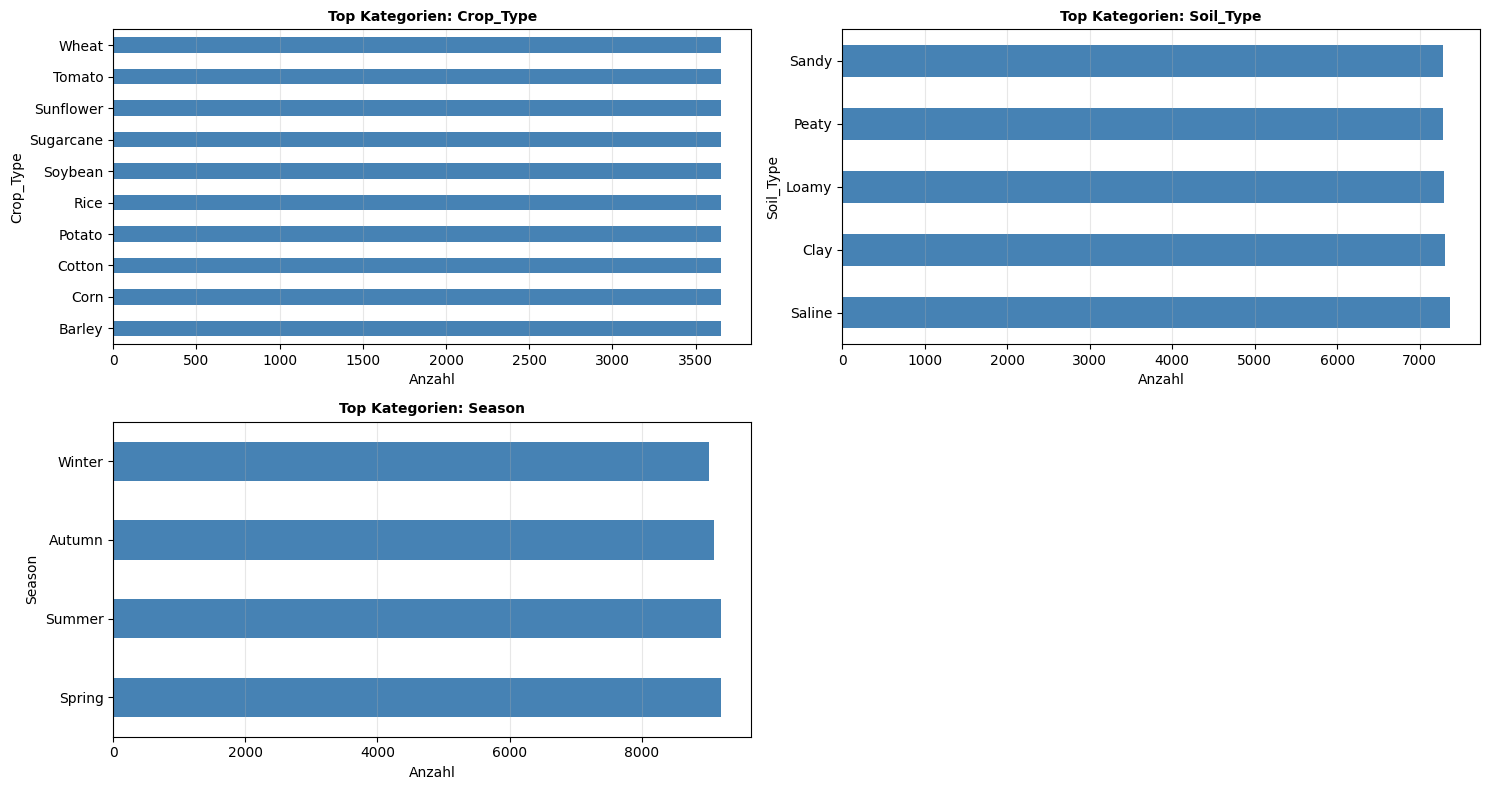

In [167]:
# Top-Kategorien visualisieren (für Spalten mit wenigen Unique-Werten)
if categorical_cols:
    low_cardinality_cols = [col for col in categorical_cols if df[col].nunique() <= 20]
    
    if low_cardinality_cols:
        n_cols = min(2, len(low_cardinality_cols))
        n_rows = (len(low_cardinality_cols) + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
        axes = axes.flatten() if len(low_cardinality_cols) > 1 else [axes]
        
        for idx, col in enumerate(low_cardinality_cols):
            ax = axes[idx]
            value_counts = df[col].value_counts().head(10)
            value_counts.plot(kind='barh', ax=ax, color='steelblue')
            ax.set_title(f'Top Kategorien: {col}', fontsize=10, fontweight='bold')
            ax.set_xlabel('Anzahl')
            ax.grid(alpha=0.3, axis='x')
        
        # Leere Subplots ausblenden
        for idx in range(len(low_cardinality_cols), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()


In [168]:
# Cross-tabulation between Crop_Type and Soil_Type
pd.crosstab(df['Crop_Type'], df['Soil_Type'])

Soil_Type,Clay,Loamy,Peaty,Saline,Sandy
Crop_Type,,,,,
Barley,702,789,726,690,745
Corn,714,738,720,748,732
Cotton,726,755,712,750,709
Potato,729,689,756,753,725
Rice,768,687,742,734,721
Soybean,711,722,732,759,728
Sugarcane,741,713,746,762,690
Sunflower,725,759,722,713,733
Tomato,752,719,703,731,747


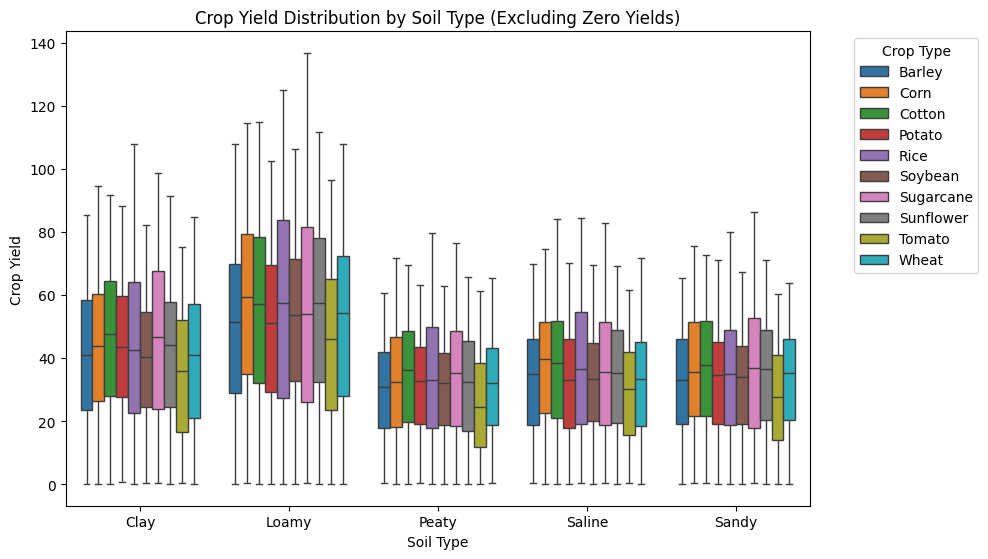

In [169]:
# Soil Type vs Crop Yield
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='Soil_Type', y='Crop_Yield', hue='Crop_Type', data=df_nonzero, ax=ax)
ax.legend(title='Crop Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_title('Crop Yield Distribution by Soil Type (Excluding Zero Yields)')
ax.set_xlabel('Soil Type')
ax.set_ylabel('Crop Yield')
fig.tight_layout(rect=[0, 0, 1, 0.95])

Loamy has better yield, followed by clay. The remaining soils seem equally bad.

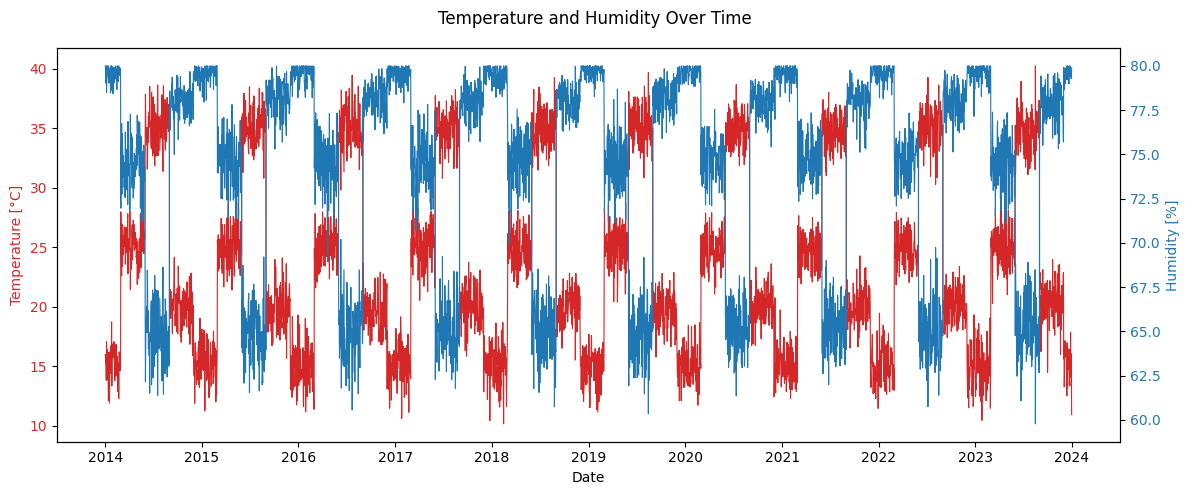

In [170]:
# Daily average temperature and humidity
daily_temp = df.groupby('Date')['Temperature'].mean().reset_index()
daily_humidity = df.groupby('Date')['Humidity'].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))

# Temperature on left axis
color1 = 'tab:red'
ax1.plot(daily_temp['Date'], daily_temp['Temperature'], color=color1, linewidth=0.8, label='Temperature')
ax1.set_xlabel('Date')
ax1.set_ylabel('Temperature [°C]', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Humidity on right axis
ax2 = ax1.twinx()
color2 = 'tab:blue'
ax2.plot(daily_humidity['Date'], daily_humidity['Humidity'], color=color2, linewidth=0.8, label='Humidity')
ax2.set_ylabel('Humidity [%]', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

fig.suptitle('Temperature and Humidity Over Time')
fig.tight_layout()
plt.show()

Strong negative correlation between temperature and humidity representative of temperate climate seasonal behavior.  
Only cyclic, no particular trend.

In [171]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Season'] = df['Date'].dt.month.apply(get_season)
df.head()

,Date,Crop_Type,Soil_Type,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality,Month,NPK_sum,NPK_balance_cv,N_ratio,P_ratio,K_ratio,Season
0,2014-01-01,Wheat,Peaty,5.50,9.440599,80.000000,10.956707,60.5,45.0,31.5,0.000000,22.833333,1,137.0,0.317770,0.441606,0.328467,0.229927,Winter
1,2014-01-01,Corn,Loamy,6.50,20.052576,79.947424,8.591577,84.0,66.0,50.0,104.871310,66.666667,1,200.0,0.255147,0.420000,0.330000,0.250000,Winter
2,2014-01-01,Rice,Peaty,5.50,12.143099,80.000000,7.227751,71.5,54.0,38.5,0.000000,27.333333,1,164.0,0.302014,0.435976,0.329268,0.234756,Winter
3,2014-01-01,Barley,Sandy,6.75,19.751848,80.000000,2.682683,50.0,40.0,30.0,58.939796,35.000000,1,120.0,0.250000,0.416667,0.333333,0.250000,Winter
4,2014-01-01,Soybean,Peaty,5.50,16.110395,80.000000,7.696070,49.5,45.0,38.5,32.970413,22.166667,1,133.0,0.124742,0.372180,0.338346,0.289474,Winter


In [180]:
df.columns.to_list()

['Date',
 'Crop_Type',
 'Soil_Type',
 'Soil_pH',
 'Temperature',
 'Humidity',
 'Wind_Speed',
 'N',
 'P',
 'K',
 'Crop_Yield',
 'Soil_Quality',
 'Month',
 'NPK_sum',
 'NPK_balance_cv',
 'N_ratio',
 'P_ratio',
 'K_ratio',
 'Season']



---

## 6. Korrelationsanalyse



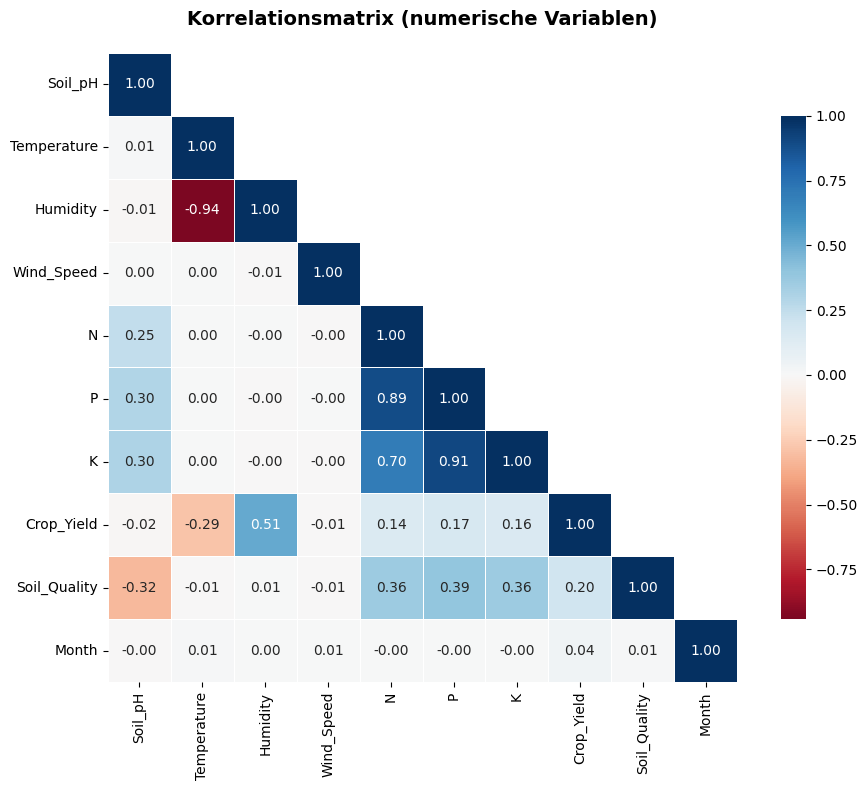


🔗 Stärkste Korrelationen (|r| > 0.5):



,Variable 1,Variable 2,Korrelation
0,Temperature,Humidity,-0.942212
4,P,K,0.906531
2,N,P,0.892132
3,N,K,0.700894
1,Humidity,Crop_Yield,0.511841


In [181]:

if len(numeric_cols) > 1:
    # Korrelationsmatrix
    corr_matrix = df[numeric_cols].corr()
    
    # Heatmap
    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # Obere Dreiecksmatrix maskieren
    
    sns.heatmap(
        corr_matrix, 
        mask=mask,
        annot=True, 
        fmt='.2f',
        cmap='RdBu', 
        center=0, 
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
        ax=ax
    )
    
    ax.set_title('Korrelationsmatrix (numerische Variablen)', 
                 fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # Stärkste Korrelationen finden
    print("\n🔗 Stärkste Korrelationen (|r| > 0.5):\n")
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.5:
                corr_pairs.append({
                    'Variable 1': corr_matrix.columns[i],
                    'Variable 2': corr_matrix.columns[j],
                    'Korrelation': corr_matrix.iloc[i, j]
                })
    
    if corr_pairs:
        corr_df = pd.DataFrame(corr_pairs).sort_values('Korrelation', 
                                                        key=abs, 
                                                        ascending=False)
        display(corr_df)
    else:
        print("Keine starken Korrelationen gefunden.")
else:
    print("⚠️ Nicht genügend numerische Variablen für Korrelationsanalyse")




---

## 7. Fehlende Werte visualisieren



In [182]:

missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

if len(missing_data) > 0:
    fig, ax = plt.subplots(figsize=(10, max(6, len(missing_data) * 0.4)))
    
    missing_percent = (missing_data / len(df) * 100)
    missing_percent.plot(kind='barh', ax=ax, color='coral')
    
    ax.set_title('Fehlende Werte pro Spalte', fontsize=12, fontweight='bold')
    ax.set_xlabel('Prozent fehlend (%)')
    ax.grid(alpha=0.3, axis='x')
    
    # Werte als Text hinzufügen
    for i, v in enumerate(missing_percent):
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center')
    
    plt.tight_layout()
    plt.show()
else:
    print("✅ Keine fehlenden Werte im Dataset!")


✅ Keine fehlenden Werte im Dataset!




---

## 8. Zusammenfassung & Bewertung



In [183]:

print("=" * 80)
print("📝 DATASET-BEWERTUNG FÜR PORTFOLIO-PROJEKT")
print("=" * 80)

# Qualitätskriterien berechnen
data_quality = {
    "Datengröße": "✅ Gut" if len(df) > 5_000 else "⚠️ Klein" if len(df) > 1_000 else "❌ Zu klein",
    "Vollständigkeit": f"✅ {(1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100:.1f}%",
    "Duplikate": "✅ Keine" if df.duplicated().sum() == 0 else f"⚠️ {df.duplicated().sum()} gefunden",
    "Variablenvielfalt": f"{'✅' if df.shape[1] >= 10 else '⚠️'} {df.shape[1]} Spalten",
    "Numerische Features": f"{'✅' if len(numeric_cols) >= 5 else '⚠️'} {len(numeric_cols)} Spalten",
    "Kategorische Features": f"{'✅' if len(categorical_cols) >= 1 else '⚠️'} {len(categorical_cols)} Spalten"
}

for criterion, status in data_quality.items():
    print(f"{criterion:.<30} {status}")

print("\n" + "=" * 80)
print("💡 EMPFEHLUNG:")
print("=" * 80)

score = sum([
    len(df) > 5000,
    df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) < 0.1,
    df.duplicated().sum() < len(df) * 0.05,
    df.shape[1] >= 10,
    len(numeric_cols) >= 5
])

if score >= 4:
    print("✅ SEHR GUT - Dieses Dataset eignet sich hervorragend für ein Portfolio-Projekt!")
elif score >= 3:
    print("👍 OK - Dieses Dataset ist für ein Portfolio-Projekt geeignet.")
else:
    print("⚠️ BEDINGT - Überlege, ob dieses Dataset für dein Projekt ausreicht.")

print("\n📌 Nächste Schritte:")
print("   1. Definiere deine Forschungsfrage")
print("   2. Identifiziere relevante Features")
print("   3. Plane deine Analysestrategie")
print("   4. Beginne mit Feature Engineering & Modeling")


📝 DATASET-BEWERTUNG FÜR PORTFOLIO-PROJEKT
Datengröße.................... ✅ Gut
Vollständigkeit............... ✅ 100.0%
Duplikate..................... ✅ Keine
Variablenvielfalt............. ✅ 19 Spalten
Numerische Features........... ✅ 10 Spalten
Kategorische Features......... ✅ 3 Spalten

💡 EMPFEHLUNG:
✅ SEHR GUT - Dieses Dataset eignet sich hervorragend für ein Portfolio-Projekt!

📌 Nächste Schritte:
   1. Definiere deine Forschungsfrage
   2. Identifiziere relevante Features
   3. Plane deine Analysestrategie
   4. Beginne mit Feature Engineering & Modeling


In [184]:
# Export curated dataset for modeling
curated_dataset_path = "../data/processed/curated_crop_yield_dataset.csv"
df.to_csv(curated_dataset_path, index=False)